In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import qnas_config as cfg
import torch
from util import plot_training_history

In [3]:
phase = 'evolution'
experiment_path = 'my_exp_config2'
config_file = 'config_files/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict

params = config.train_spec

net_list = ['conv_3_1_256','no_op', 'conv_3_1_128', 'no_op','no_op','no_op',
            'conv_3_1_64','conv_3_1_64','no_op','conv_3_1_256','conv_3_1_256',
            'max_pool_2_2', 'conv_3_1_128', 'no_op','no_op','no_op','no_op','no_op',
            'max_pool_2_2', 'conv_3_1_128']

In [4]:
# create a list with all available cuda devices
device_list = [f'cuda:{i}' for i in range(torch.cuda.device_count())]
device_list

['cuda:0', 'cuda:1', 'cuda:2']

In [5]:
params['device'] = device_list[2]
params['device']

'cuda:2'

In [6]:
from cnn.train import fitness_calculation
data = {"num_classes": 10}

# AdamW

In [7]:
results_dict = fitness_calculation(id_num="job_0", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
results_dict["best_accuracy"]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training Fitness Scheme:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch [2/300] - Training loss: 2.5243987549435007 - Validation loss: 1.7880791902542115 - Validation accuracy: 43.1%
Epoch [3/300] - Training loss: 2.3411842212080956 - Validation loss: 2.1495923519134523 - Validation accuracy: 45.9%
Epoch [4/300] - Training loss: 2.1842324395071375 - Validation loss: 1.6379456043243408 - Validation accuracy: 50.02%
Epoch [5/300] - Training loss: 2.133591140535745 - Validation loss: 1.4303372144699096 - Validation accuracy: 53.0%
Epoch [6/300] - Training loss: 2.0340635613961653 - Validation loss: 1.9121456623077393 - Validation accuracy: 52.96%
Epoch [7/300] - Training loss: 1.9149549075148322 - Validation loss: 1.7417332649230957 - Validation accuracy: 55.8%
Epoch [8/300] - Training loss: 1.9065033400600606 - Validation loss: 2.078326177597046 - Validation accuracy: 58.4%
Epoch [9/300] - Training loss: 1.839740058237856 - Validation loss: 5.145329093933105 - Validation accuracy: 53.22%
Epoch [10/300] - Training loss: 1.7647712007164955 - Validation l

89.68

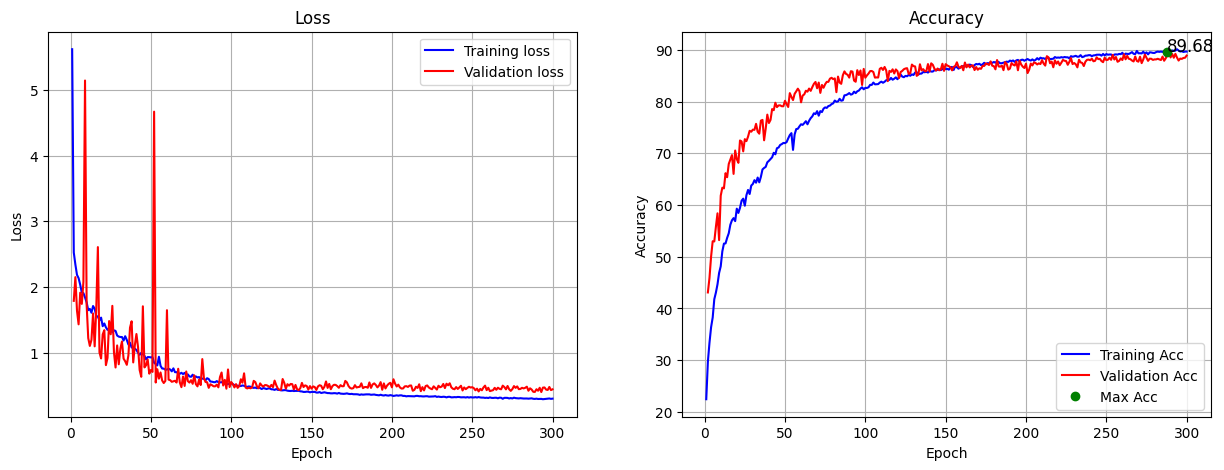

In [8]:
plot_training_history(results_dict, params)

# Adam

In [9]:
params['optimizer'] = 'Adam'

In [10]:
results_dict_1 = fitness_calculation(id_num="job_3", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
results_dict_1["best_accuracy"]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training Fitness Scheme:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch [2/300] - Training loss: 1.936220222576098 - Validation loss: 1.5060041904449464 - Validation accuracy: 50.44%
Epoch [3/300] - Training loss: 1.7535384561527858 - Validation loss: 2.3373334407806396 - Validation accuracy: 51.54%
Epoch [4/300] - Training loss: 1.6420252986929633 - Validation loss: 1.5131810903549194 - Validation accuracy: 56.4%
Epoch [5/300] - Training loss: 1.4322375919331203 - Validation loss: 1.6684015274047852 - Validation accuracy: 59.18%
Epoch [6/300] - Training loss: 1.4499852244149556 - Validation loss: 1.2624396324157714 - Validation accuracy: 61.76%
Epoch [7/300] - Training loss: 1.325754204256968 - Validation loss: 1.2798566341400146 - Validation accuracy: 63.88%
Epoch [8/300] - Training loss: 1.2471294992349364 - Validation loss: 1.6495025634765625 - Validation accuracy: 62.94%
Epoch [9/300] - Training loss: 1.2681162337010556 - Validation loss: 1.0081438660621642 - Validation accuracy: 67.46%
Epoch [10/300] - Training loss: 1.1957474750551311 - Valida

86.64

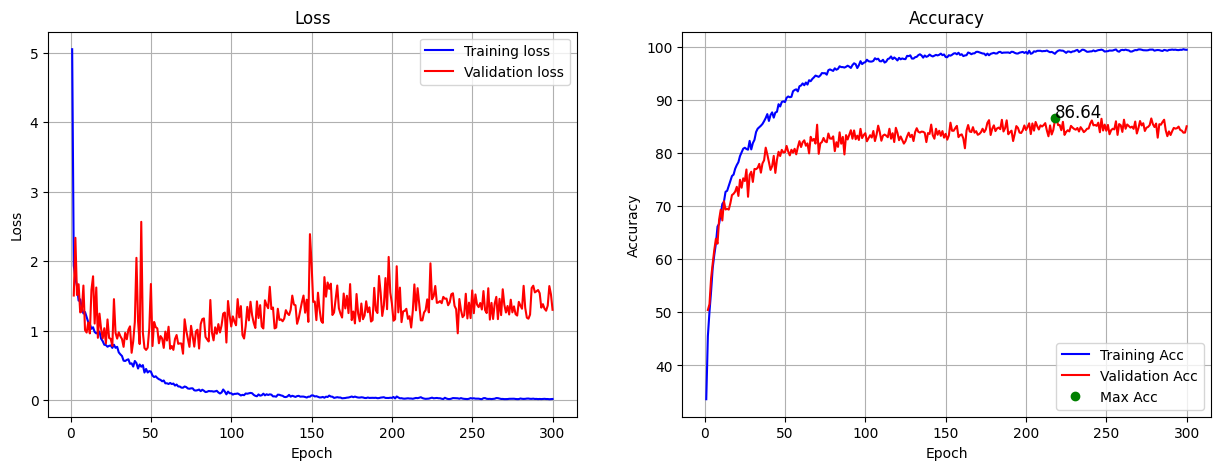

In [11]:
plot_training_history(results_dict_1, params)